# Credit Risk Modelling with the German Credit Dataset

## Introduction

This notebook is the supplementary code for the Credit Risk Report, exploring the German Credit Dataset. It is in the same structure as the report to aid navigation.

The workflow covers:

- Data loading and quality checks
- Exploratory analysis
- Preprocessing for modelling
- Model development and evaluation (Logistic and Decision Tree Models)
- Threshold analysis 

## Preparation

### Data Preparation & Preprocessing

Import all the packages used during this project, used for data preparation, visualisation, modelling, and evaluation.

In [1250]:
#Data manipulation and analysis libraries
import pandas as pd
import numpy as np

#Data visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

#Importing table visualisation library
import dataframe_image as dfi

#Modelling and evaluation libraries
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

The dataset consists of a mix of numerical and categorical variables describing borrower characteristics.

As the dataset does not include column labels, they need to be assigned manually.

In [1251]:
#column names for the dataset
columns = [
    'checking_account', 'duration', 'credit_history', 'purpose',
    'credit_amount', 'savings_account', 'employment_since',
    'installment_rate', 'personal_status_sex', 'other_debtors',
    'residence_since', 'property', 'age', 'other_installment_plans',
    'housing', 'existing_credits', 'job', 'num_dependents',
    'telephone', 'foreign_worker', 'target'
]
#Load the data and assign column names
df = pd.read_csv("german.data", sep=" ", header=None)
df.columns = columns

#Check to see if the column names have been applied correctly
df.head()


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


The dataset has loaded correctly, so we can move onto checking the dataset.

### Data Quality

First, the dataset is checked for missing entries.

In [1252]:
#Overview of the dataset including missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_account         1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings_account          1000 non-null   object
 6   employment_since         1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

No missing values identified. 

Next a check for any duplicate rows.

In [1253]:
#Gives the number of duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

No duplicates found. Then irregular data values are looked for.

In [1254]:
#Shows all the unique values in categorical columns
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique())

checking_account ['A11' 'A12' 'A14' 'A13']
credit_history ['A34' 'A32' 'A33' 'A30' 'A31']
purpose ['A43' 'A46' 'A42' 'A40' 'A41' 'A49' 'A44' 'A45' 'A410' 'A48']
savings_account ['A65' 'A61' 'A63' 'A64' 'A62']
employment_since ['A75' 'A73' 'A74' 'A71' 'A72']
personal_status_sex ['A93' 'A92' 'A91' 'A94']
other_debtors ['A101' 'A103' 'A102']
property ['A121' 'A122' 'A124' 'A123']
other_installment_plans ['A143' 'A141' 'A142']
housing ['A152' 'A153' 'A151']
job ['A173' 'A172' 'A174' 'A171']
telephone ['A192' 'A191']
foreign_worker ['A201' 'A202']


'A410' in purpose looks odd as it is the only one in the category that consists of 3 integers, but a quick check tells us its a normal value.

By seeing minimum, maximum and quartiles of each of numerical variable, impossible or unfeasible values can be located.

In [1255]:
#Gives summary statistics for numerical columns
df.describe()

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


There are no negative values, however, the variables 'credit_amount' and 'duration' have very large maximum values, so boxplots are used to look for potential outliers.

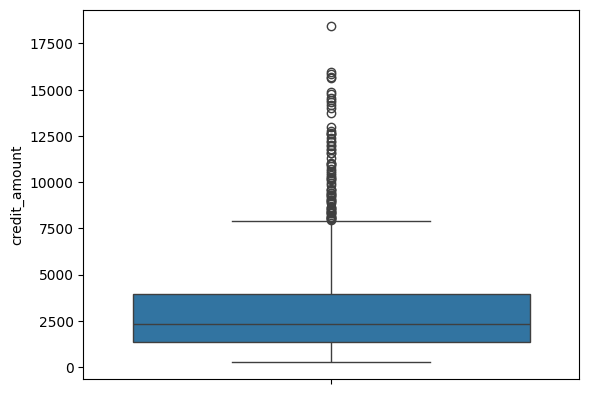

In [1256]:
#Boxplot for credit_amount
sns.boxplot(df['credit_amount'])
plt.show()

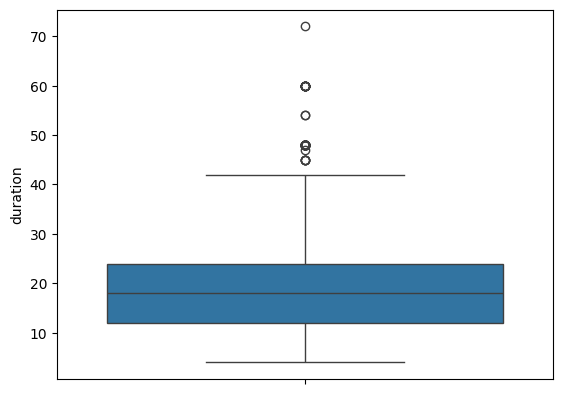

In [1257]:
#Boxplot for duration
sns.boxplot(df['duration'])
plt.show()

The extreme values are kept as they are plausible in a lending context.

The distribution of credit_amount is potentially skewed, which is looked at later.

### The Target Variable

Regression models predict values of 0 and 1, or -1 and 1, so to fit this requirement the values are changed so that 0 means non-default and 1 means default.

In [1258]:
#Converts target variable to desired format
df["target"] = df["target"].astype(int)
df["target"] = df["target"].replace({1: 0, 2: 1})

#Shows the unique target values to check if the change was successful
print("Target values:", df["target"].unique())

Target values: [0 1]


### Basic Analysis

Start by examining class balance, and the distribution of the numerical variables.

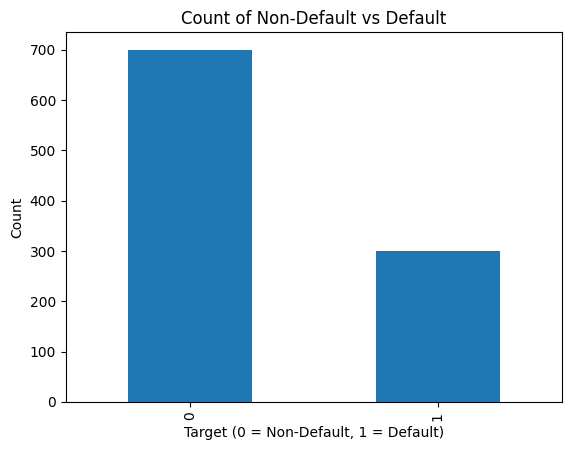

In [1259]:
#Bar chart for the distribution of the target variable
df['target'].value_counts().plot(kind='bar')
plt.title('Count of Non-Default vs Default')
plt.xlabel('Target (0 = Non-Default, 1 = Default)')
plt.ylabel('Count')
plt.show()

The dataset is imbalanced, consisting of many more non-defaulters than defaulters, which could affect model performance.

The other numerical variables distributions are looked at.

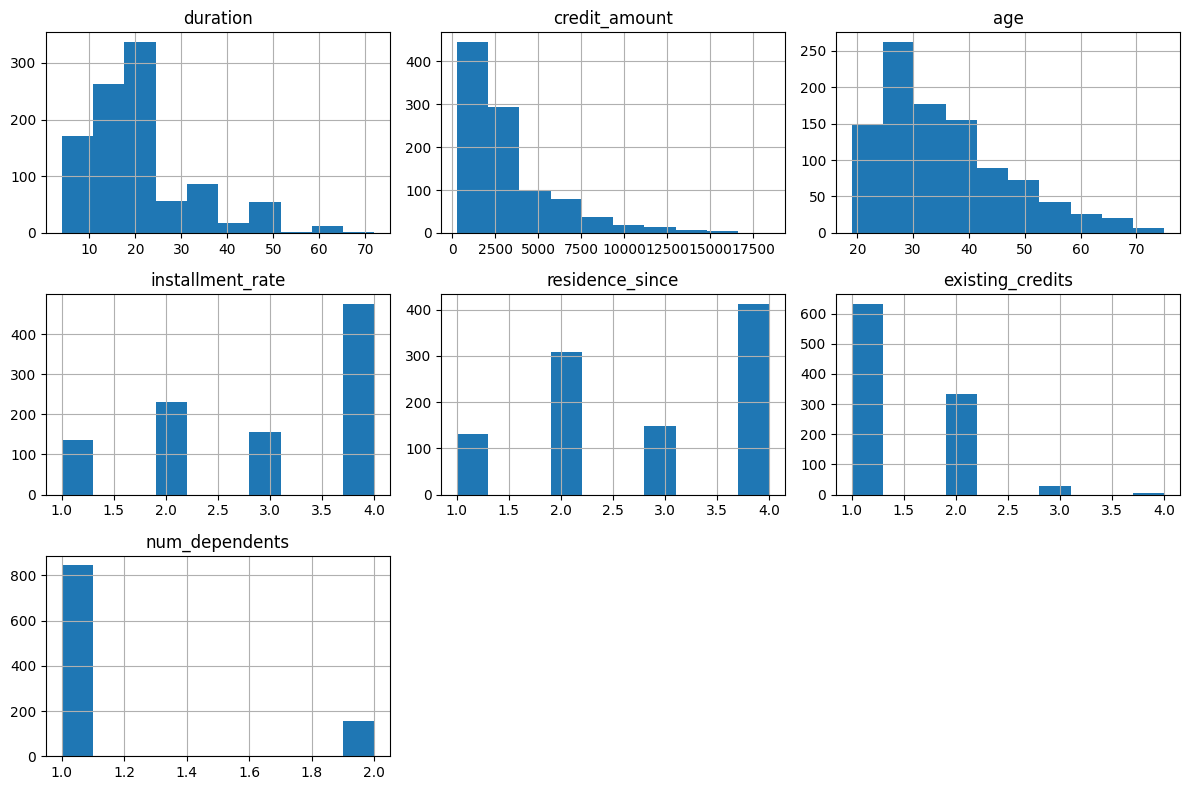

In [1260]:
#List of the numerical variables in the dataset
numerical_cols = ['duration', 'credit_amount', 'age', 'installment_rate',
                   'residence_since', 'existing_credits', 'num_dependents']

#Histograms for the numerical variables
df[numerical_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

Some variables may be skewed, especially 'credit_amount'.

In [1261]:
# Create table to show mean values of key numerical features for each category of the target variable
group_means = df.groupby('target')[['duration', 'credit_amount', 'age']].mean().round(2)
group_means

,duration,credit_amount,age
target,,,
0,19.21,2985.46,36.22
1,24.86,3938.13,33.96


Defaulters tend to have:
- Higher average credit amounts
- Longer loan durations
- Slightly lower average age

### Data Preprocessing

Categorical variables are one-hot encoded.

In [1262]:
#Encodes categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

#Check the first few rows to see if it worked
df_encoded.head()

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,target,checking_account_A12,checking_account_A13,...,property_A124,other_installment_plans_A142,other_installment_plans_A143,housing_A152,housing_A153,job_A172,job_A173,job_A174,telephone_A192,foreign_worker_A202
0,6,1169,4,4,67,2,1,0,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,1,True,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,0,False,False,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,0,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,1,False,False,...,True,False,True,False,True,False,True,False,False,False


Data is split into input features and target variable. Then split into training and testing datasets.

An 80/20 split is used for model evaluation.

In [1263]:
#Separate features and target variable
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

#Split the data into training and testing sets. Random state is set to make it reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

## Logistic Regression Model

### Fitting the Model

Scaling is applied to the input features before fitting the model, as logistic regression performs better when the data is scaled.

In [1264]:
#Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Fit the logistic regression model
model = LogisticRegression(max_iter=100)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Performance

In [1265]:
#Predict probabilities and classes for the test set
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

#Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.795


A confusion matrix is used to see where the classification errors are made.

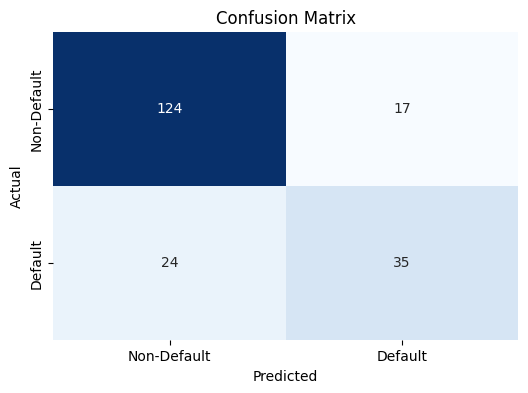

In [1266]:
#Create confusion matrix
cm_lr = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
#Improve visualisation using a heatmap
sns.heatmap(cm_lr, 
            annot=True, 
            fmt="d", 
            cmap="Blues",
            cbar=False,
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default']
            )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

It shows higher accuracy on non-defaults than defaults, which is likely a result of the class imbalance.

The exact statistics are below.

In [1267]:
#Print classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       141
           1       0.67      0.59      0.63        59

    accuracy                           0.80       200
   macro avg       0.76      0.74      0.74       200
weighted avg       0.79      0.80      0.79       200



A ROC curve evaluates performance across thresholds.

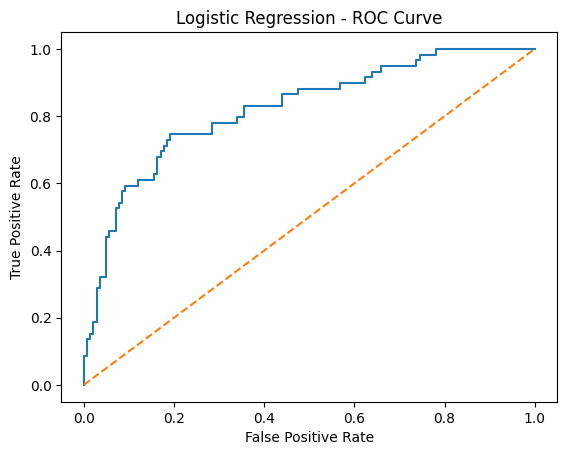

In [1268]:
#Plot ROC curve
fpr, tpr, threshes = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression - ROC Curve')
plt.show()

The ROC AUC measures this numerically:

In [1269]:
roc = roc_auc_score(y_test, y_prob)
print('ROC AUC:', roc)

ROC AUC: 0.8210121408823177


Indicates good classification performance.

### Skewed Data 

Earlier 'credit_amount' appeared skewed, so a transformation is explored.

A log transformation makes the distribution of 'credit_amount' more symmetrical.

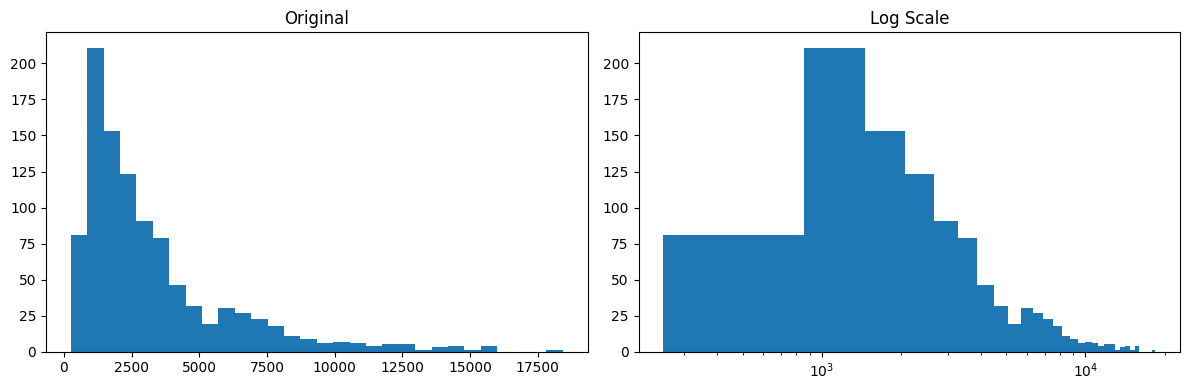

In [1270]:
#Plotting the distribution of the credit_amount variable before and after log transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#Original histogram
axes[0].hist(df['credit_amount'], bins=30)
axes[0].set_title('Original')

#Log scaled histogram
axes[1].hist(df['credit_amount'], bins=30)
axes[1].set_xscale('log')
axes[1].set_title('Log Scale')

plt.tight_layout()
plt.show()

### Is a transformation worth it?

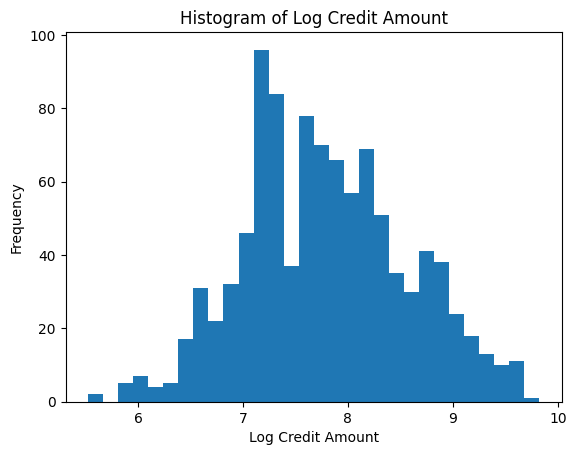

In [1271]:
#Copy of the data is made to transform
df_log = df.copy()

#Log transformation is applied to credit_amount
df_log['credit_amount'] = np.log(df_log['credit_amount'] + 1)  # Adding 1 to avoid log(0)

#Histogram of the log transformed credit_amount variable
plt.hist(df_log['credit_amount'], bins=30)
plt.xlabel('Log Credit Amount')
plt.ylabel('Frequency')
plt.title('Histogram of Log Credit Amount')
plt.show()

The data is processed again, and a new model is fitted to the transformed data.

In [1272]:
#Encoding
df_log_encoded = pd.get_dummies(df_log, drop_first=True)

#Seperating data into features and target variable
X_log = df_log_encoded.drop('target', axis=1)
y_log = df_log_encoded['target']

#Test train split
X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
    )

#Scaling the features
scaler = StandardScaler()
X_log_train_scaled = scaler.fit_transform(X_log_train)
X_log_test_scaled = scaler.transform(X_log_test)

#Fit the model to the scaled log transformed data
model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_log_train_scaled, y_log_train)

#Predict probabilities and classes for the test set
y_log_pred = model_log.predict(X_log_test_scaled)
y_log_prob = model_log.predict_proba(X_log_test_scaled)[:, 1]

In [1273]:
#Evaluate the model's accuracy
accuracy_log = accuracy_score(y_log_test, y_log_pred)
print('Log Transformed Accuracy:', accuracy_log)

Log Transformed Accuracy: 0.795


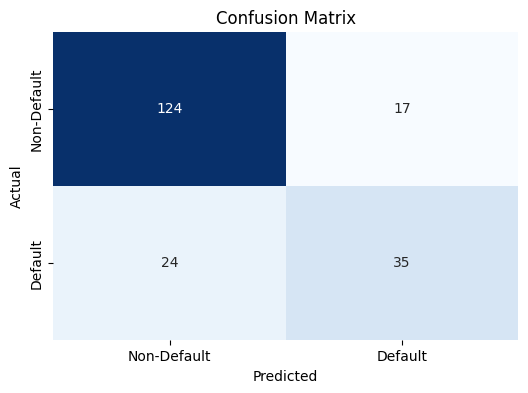

In [1274]:
#Plot confusion matrix for the log transformed model
cm_llr = confusion_matrix(y_log_test, y_log_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_llr, 
            annot=True, 
            fmt="d", 
            cmap="Blues",
            cbar=False,
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default']
            )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The transformation had no effect, so is not worth including.

### Coefficient Analysis

Examining the variables that affect default risk the most.

In [1275]:
#Show the top largest positive coefficients for the original model
coeffs = pd.Series(model.coef_[0], index=X.columns)
top_coeffs = (
    coeffs
    .sort_values(ascending=False)
    .head(10)
    .rename_axis("Feature")
    .reset_index(name="Coefficient")
)

top_coeffs

,Feature,Coefficient
0,credit_amount,0.368259
1,installment_rate,0.348594
2,job_A173,0.340541
3,job_A174,0.256531
4,duration,0.247415
5,job_A172,0.221647
6,existing_credits,0.200312
7,property_A124,0.194881
8,property_A122,0.143054
9,property_A123,0.111777


Credit amount and installment rate are strong positive drivers of default risk. This indicates that larger loans and higher repayment rates increase likelihood of default.

In [1276]:
#Show the top largest negative coefficients for the original model
bottom_coeffs = (
    coeffs
    .sort_values(ascending=True)
    .head(10)
    .rename_axis("Feature")
    .reset_index(name="Coefficient")
)

bottom_coeffs

,Feature,Coefficient
0,checking_account_A14,-0.778400
1,credit_history_A34,-0.644213
2,purpose_A41,-0.494762
3,personal_status_sex_A93,-0.454389
4,purpose_A43,-0.416326
5,purpose_A42,-0.353386
6,age,-0.319224
7,other_installment_plans_A143,-0.286938
8,credit_history_A32,-0.282058
9,credit_history_A33,-0.281358


'checking_account_A14' corresponds to a borrower with no checking account, while 'credit_history_A34' represents borrowers with no previous credit issues.

A strong negative coefficient for 'credit_history_A34' suggests that a borrower's past repayment behaviour is a strong indicator of their future creditworthiness. Individuals who have consistently paid back previous loans are less likely to default.

### Probability Calibration

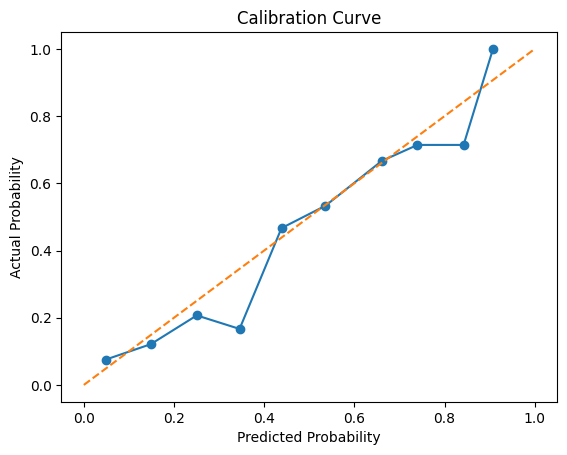

In [1277]:
#Plotting the calibration curve for the original model
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('Predicted Probability')
plt.ylabel('Actual Probability')
plt.title('Calibration Curve')
plt.show()

Model is well calibrated, but slightly overestimates risk at certain probablities.

## Decision Tree Model

### Fitting and Assessing the Model

A decision tree is fitted to capture potential non-linear relationships.

In [1278]:
#Fit a decision tree model to the data
tree_model = DecisionTreeClassifier(max_depth=3, random_state=5)
tree_model.fit(X_train, y_train)

#Predict probabilities and classes for the test set
tree_pred = tree_model.predict(X_test)
tree_prob = tree_model.predict_proba(X_test)[:, 1]

The same performance measures used for the logistic regression model are evaluated.

In [1279]:
accuracy_dec = accuracy_score(y_test, tree_pred)
print('Accuracy:', accuracy_dec)

Accuracy: 0.76


0.76 is lower than the logistic regression's accuracy of 0.795.

The confusion matrix for the decision tree model is below.

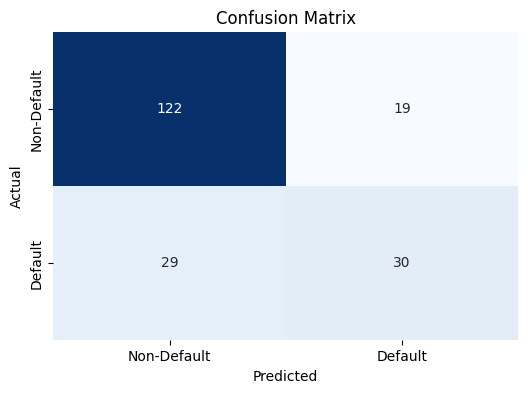

In [1280]:
#Plot confusion matrix for the decision tree model
cm_tm = confusion_matrix(y_test, tree_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_tm, 
            annot=True, 
            fmt="d", 
            cmap="Blues",
            cbar=False,
            xticklabels=['Non-Default', 'Default'],
            yticklabels=['Non-Default', 'Default']
            )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Similar performance to logistic regression. The decision tree also performs better on predicting non-defaulters.

In [1281]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       141
           1       0.61      0.51      0.56        59

    accuracy                           0.76       200
   macro avg       0.71      0.69      0.70       200
weighted avg       0.75      0.76      0.75       200



Weaker recall for defaulters than logistic regression, so worse at identifying high-risk borrowers.

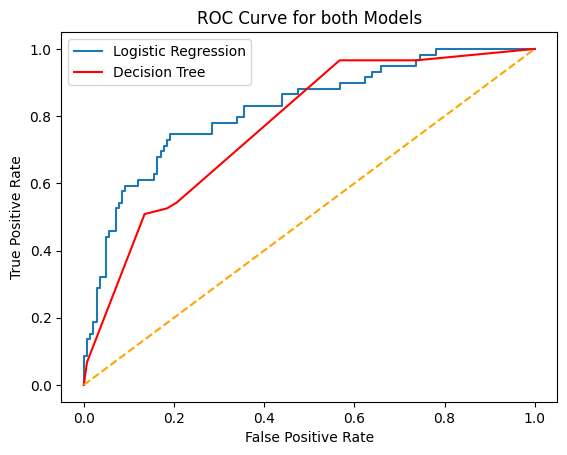

In [1282]:
#Plot ROC curve for both models
fpr_tm, tpr_tm, _ = roc_curve(y_test, tree_prob)

plt.plot(fpr, tpr)
plt.plot(fpr_tm, tpr_tm, color='red')
plt.legend(['Logistic Regression', 'Decision Tree'])
plt.plot([0, 1], [0, 1], linestyle='--', color='orange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for both Models')
plt.show()

The decision tree ROC curve lies closer to the diagonal, meaning it is weaker at comparing high risk and low risk borrowers.

This is reinforced by comparing ROC AUCs.

In [1283]:
roc_tree = roc_auc_score(y_test, tree_prob)
print('ROC AUC for Decision Tree:', roc_tree)

ROC AUC for Decision Tree: 0.7692631325880515


This AUC is lower than logistic regression's AUC of ~ 0.82.

### Probability Calibration

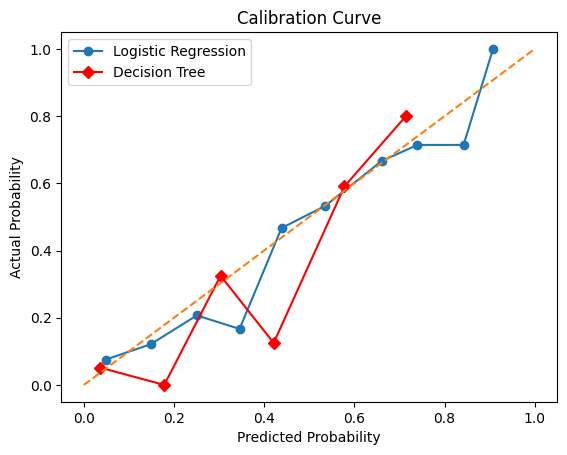

In [1284]:
#Plotting the calibration curve for both models
prob_tree_true, prob_tree_pred = calibration_curve(y_test, tree_prob, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot(prob_tree_pred, prob_tree_true, marker='D', color='red')
plt.legend(['Logistic Regression', 'Decision Tree'])
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('Predicted Probability')
plt.ylabel('Actual Probability')
plt.title('Calibration Curve')
plt.show()

The decision tree's calibration is less stable than the logistic regression's, and it also has poorer probability estimates.

### Conclusion on the Models

The logistic model outperforms the decision tree in every metric and is therefore preferred as the final model.

## Threshold Analysis

### Threshold Meaning

Predictions are based on probability thresholds. The default threshold is 0.5, but this may not be optimal in a risk environment.

In [1285]:
rows = []

for i in range(1, 6):
    thresh = i / 10
    y_pred_custom = (y_prob > thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()

    approvals = tn + fn
    approval_rate = approvals / len(y_test)
    default_rate_approved = fn / approvals if approvals > 0 else 0

    rows.append({
        "Threshold": thresh,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Approvals": approvals,
        "Approval Rate": approval_rate,
        "Default Rate Among Approvals": default_rate_approved
    })

threshold_df = pd.DataFrame(rows)
threshold_df

,Threshold,TN,FP,FN,TP,Approvals,Approval Rate,Default Rate Among Approvals
0,0.1,49,92,4,55,53,0.265,0.075472
1,0.2,78,63,8,51,86,0.430,0.093023
2,0.3,101,40,14,45,115,0.575,0.121739
3,0.4,116,25,17,42,133,0.665,0.127820
4,0.5,124,17,24,35,148,0.740,0.162162


False negatives (FN) are when defaulters are approved for loans. These are costly and need to be minimised. False positives (FP) are when non-defaulters are rejected for loans. These are less costly.

Therefore lower thresholds may be preferable. By assigning the profit per loan and loss per default, an optimal threshold can be found.

In [1286]:
#Assigning values
profit_gen = 1000
loss_default = -10000

#Iteration is the number of thresholds we want to evaluate
n_steps = 5

#Denominator is used to calculate the threshold values. For example, if iter is 5 and denominator is 10, the thresholds will be 0.1, 0.2, 0.3, 0.4 and 0.5.
denominator = 10

#Function to produce profit tables given different profits and losses over a range of thresholds
def profit_table(profit_per_non_default, loss_per_default, y_prob, y_test, n_steps, denominator):
    """
    Computes profit across a range of thresholds and returns a DataFrame with the results.
    
    Parameters:
        - profit_per_non_default: Profit for each approved non-default case
        - loss_per_default: Loss for each approved default case
        - y_prob: Predicted probabilities for the positive class
        - y_test: True labels for the test set
        - n_steps: Number of thresholds to evaluate
        - denominator: Used to calculate threshold values (thresholds will be i/denominator for i in 1 to n_steps)
        
    Returns:
        - DataFrame with columns: Threshold, Profit, Approvals, Approval Rate, Defaults, Default Rate
    """
    results_list = []
    for i in range(1,n_steps+1):
        thresh = i/denominator
        y_pred_custom = (y_prob > thresh).astype(int)
        approvals = sum(y_pred_custom==0)
        approval_rate = approvals / len(y_test) if len(y_test) > 0 else 0
        defaults = sum((y_pred_custom == 0) & (y_test == 1))
        default_rate = defaults / approvals if approvals > 0 else 0
        profit = (approvals-defaults) * profit_per_non_default + defaults * loss_per_default
        results_list.append([thresh, profit, approvals, approval_rate, defaults, default_rate])

    results_df = pd.DataFrame(results_list, columns=["Threshold", "Profit", "Approvals","Approval Rate", "Defaults", "Default Rate"])
    return results_df

#Generate and display the profit table
results_df = profit_table(profit_gen, loss_default, y_prob, y_test, iter, denominator)
results_df

,Threshold,Profit,Approvals,Approval Rate,Defaults,Default Rate
0,0.1,9000,53,0.265,4,0.075472
1,0.2,-2000,86,0.430,8,0.093023
2,0.3,-39000,115,0.575,14,0.121739
3,0.4,-54000,133,0.665,17,0.127820
4,0.5,-116000,148,0.740,24,0.162162


Profit varies significantly depending on threshold. Using the baseline threshold results in a large loss.

### Interpreting Thresholds

Using larger values of iter and denominator for the profit table function allows more optimal thresholds to be found.

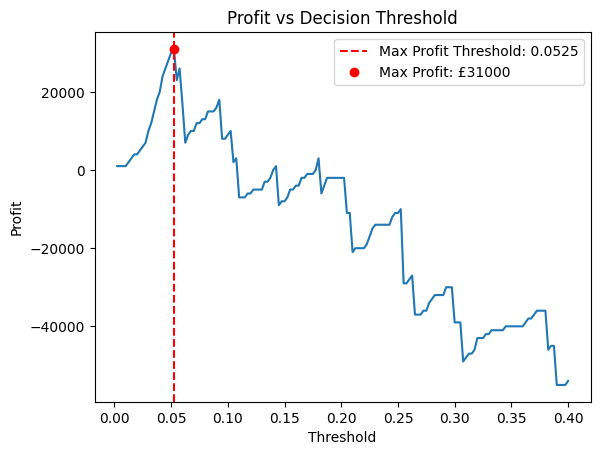

Maximum Profit: £31000
Optimal Threshold: 0.0525


In [1287]:
#Setting values for a more detailed profit table
n_steps_1 = 160
denominator_1 = 400
results_df_1 = profit_table(profit_gen, loss_default, y_prob, y_test, n_steps_1, denominator_1)

#Finding the threshold that gives the maximum profit, and then the corresponding profit value
max_index = np.argmax(results_df_1['Profit'])
max_threshold = results_df_1.loc[max_index, 'Threshold']
max_profit = results_df_1.loc[max_index, 'Profit']

#Plotting profit against threshold
plt.plot(results_df_1['Threshold'], results_df_1['Profit'])
plt.axvline(x=max_threshold, color='red', linestyle='--', label=f'Max Profit Threshold: {max_threshold:.4f}')
plt.plot(max_threshold, max_profit, 'ro', label=f'Max Profit: £{max_profit:.0f}')
plt.xlabel('Threshold')
plt.ylabel('Profit')
plt.title('Profit vs Decision Threshold')
plt.legend()
plt.show()

#Print the maximum profit and the optimal threshold
print(f"Maximum Profit: £{max_profit}")
print(f"Optimal Threshold: {max_threshold}")

So, a much lower threshold than 0.5 is optimal.

### Limitations

Key limitations of this approach is that we know our logistic model was not completely accurate to reality so that would affect how the thresholds perform in reality.

It is overly simplistic to assume constant profit and loss per loan. 

The assumed values of profit and loss were arbitrary and the threshold will depend on their values.

In [1288]:
#Set values for an alternative profit table
profit_gen_2 = 1000
loss_default_2 = -5000

#Create and display the alternative profit table
results_df_2 = profit_table(profit_gen_2, loss_default_2, y_prob, y_test, n_steps, denominator)
results_df_2

,Threshold,Profit,Approvals,Approval Rate,Defaults,Default Rate
0,0.1,29000,53,0.265,4,0.075472
1,0.2,38000,86,0.430,8,0.093023
2,0.3,31000,115,0.575,14,0.121739
3,0.4,31000,133,0.665,17,0.127820
4,0.5,4000,148,0.740,24,0.162162


## Final Recommendation

- Select the logistic regression as the final model
- Threshold of ~ 0.05 is optimal when incorporating business costs

Model performance alone is not sufficient, decisions must also reflect the cost structure of the loans.